## Assignment
@Author: **xx**

In [18]:
# ============================================================
# 
# Import necessary libraries
# 
# ============================================================

import re
import itertools
import numpy as np
import pandas as pd

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/carside/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/carside/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/carside/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
# Import the dataset as dataframe first.
dataset = pd.read_csv("dataset.tsv", sep="\t")
dataset.head(3)

,authors,title,genre,summary
0,Suzanne Collins,"The Hunger Games (The Hunger Games, #1)",young_adult,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...
1,"J.K. Rowling, Mary GrandPré",Harry Potter and the Sorcerer's Stone (Harry P...,fantasy,Harry Potter's life is miserable. His parents ...
2,Stephenie Meyer,"Twilight (Twilight, #1)",young_adult,About three things I was absolutely positive. ...


In [3]:
df = pd.DataFrame({'book_content': dataset.summary, 'genre':dataset.genre})

df.head(2)

,book_content,genre
0,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,young_adult
1,Harry Potter's life is miserable. His parents ...,fantasy


### Part 1 - Q1

(i)

The original regex may be too aggressive 

because it removes all punctuation and special symbols by deletion. 

This can merge words and destroy informative genre-related expressions.

For example, "science-fiction" becomes "sciencefiction", which is no longer a valid word.

Instead, I will choose an empty space to replace punctuation and symbols, such that

merging words can be avoided.

(ii)

A single random training-test split is not reliable 

because the result may depend heavily on one particular split of the data. 

To obtain a more stable estimate of model performance, 

I have chosen stratified k-fold(k=5) cross-validation,

because it keeps the distribution approximately consistent across folds, which is better.

### Part 1 - Q2

To choose the best preprocessing strategy, 

I tested different combinations of 

special character handling, word definition, stopword removal, lowercasing, and 

stemming/lemmatization. 

Each setup was evaluated using stratified 5-fold cross-validation.

The best overall preprocessing setup was: 

1. lowercase the text, 

2. replace special characters with spaces, 

3. keep alphabetic words only, 

4. do not remove stopwords, 
5. and apply Porter stemming. 

Replacing special characters with spaces avoids incorrectly merging words.

With this preprocessing setup, 

BNB achieved a mean accuracy of 0.66525 with a standard deviation of 0.00917, 

while MNB achieved a mean accuracy of 0.72775 with a standard deviation of 0.01094. 

The overall mean accuracy was 0.69650, which was the best among the tested configurations. 

Therefore, I will use this preprocessing setup for the rest of the assignment.

In [6]:
# Stopword lists
nltk_stopwords = set(stopwords.words("english"))
sklearn_stopwords = set(ENGLISH_STOP_WORDS)

# Stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Text preprocessing function.
def preprocess_text(
    text,
    lowercase=True, char_mode="space",
    word_mode="alpha", stopword_mode="nltk", normalization_mode="stem"
):
    """
    Preprocess a text string before CountVectorizer.

    Parameters
    ----------
    lowercase:
        Whether to lowercase the text. CountVectorizer() also lowercases by default,
        but we keep this explicit for clarity.

    char_mode:
        "delete" -> remove special characters directly.
                    Example: science-fiction -> sciencefiction
        "space"  -> replace special characters with spaces.
                    Example: science-fiction -> science fiction

    word_mode:
        "alpha" -> keep alphabetic words only.
        "alnum" -> keep alphabetic and numeric tokens.

    stopword_mode:
        "none" -> do not remove stopwords.
        "nltk" -> remove NLTK English stopwords.
        "sklearn" -> remove scikit-learn English stopwords.

    normalization_mode:
        "none" -> no stemming or lemmatization.
        "stem" -> Porter stemming.
        "lemma" -> WordNet lemmatization.
    """

    # 1. Lowercasing the words.
    if lowercase:
        text = text.lower()

    # 2. Special character handling
    if char_mode == "delete":
        # directly delete special characters(Tutorial default setting, for comparison use)
        text = re.sub(r"[^A-Za-z0-9\s]", "", text)

    elif char_mode == "space":
        # replace special characters with spaces
        # science-fiction -> science fiction
        text = re.sub(r"[^A-Za-z0-9\s]", " ", text)

    else:
        raise ValueError("char_mode must be either 'delete' or 'space'.")

    # 3. word selection
    if word_mode == "alpha":
        # Alphabetic tokens only, length >= 2
        tokens = re.findall(r"\b[a-zA-Z]{2,}\b", text)

    elif word_mode == "alnum":
        # Alphabetic or numeric tokens, length >= 2
        tokens = re.findall(r"\b[a-zA-Z0-9]{2,}\b", text)

    else:
        raise ValueError("word_mode must be either 'alpha' or 'alnum'.")

    # 4. Stopword removal
    if stopword_mode == "nltk":
        tokens = [t for t in tokens if t not in nltk_stopwords]

    elif stopword_mode == "sklearn":
        tokens = [t for t in tokens if t not in sklearn_stopwords]

    elif stopword_mode == "none":
        pass

    else:
        raise ValueError("stopword_mode must be 'none', 'nltk', or 'sklearn'.")

    # 5. Stemming or lemmatization.
    if normalization_mode == "stem":
        tokens = [stemmer.stem(t) for t in tokens]

    elif normalization_mode == "lemma":
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    elif normalization_mode == "none":
        pass

    else:
        raise ValueError("normalization_mode must be 'none', 'stem', or 'lemma'.")

    return " ".join(tokens)

In [ ]:
# Lowercasing is kept as True because CountVectorizer() lowercases by default.
# I still keep it here explicitly to make the preprocessing decision clear.

config_grid = {
    "lowercase": [True],
    "char_mode": ["delete", "space"],
    "word_mode": ["alpha", "alnum"],
    "stopword_mode": ["none", "nltk", "sklearn"],
    "normalization_mode": ["none", "stem", "lemma"]
}

preprocessing_configs = []

for values in itertools.product(*config_grid.values()):
    config = dict(zip(config_grid.keys(), values))
    preprocessing_configs.append(config)

print("Number of preprocessing configurations:", len(preprocessing_configs))
preprocessing_configs[:5]

Number of preprocessing configurations: 36


[{'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'none',
  'normalization_mode': 'none'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'none',
  'normalization_mode': 'stem'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'none',
  'normalization_mode': 'lemma'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'nltk',
  'normalization_mode': 'none'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'nltk',
  'normalization_mode': 'stem'}]

In [8]:
bnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),   # default settings
    ("classifier", BernoulliNB())        # default settings
])

mnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),   # default settings
    ("classifier", MultinomialNB())      # default settings
])

# StratifiedKFold cross-validation k=5
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Change these column names if your dataframe uses different names
TEXT_COL = "book_content"
LABEL_COL = "genre"

# Make a clean copy for experiments
data = df[[TEXT_COL, LABEL_COL]].copy()

# Remove rows with missing text or label
data = data.dropna(subset=[TEXT_COL, LABEL_COL])

# Ensure text is string
data[TEXT_COL] = data[TEXT_COL].astype(str)

texts = data[TEXT_COL]
labels = data[LABEL_COL]

print("Number of samples:", len(data))
print("Genre distribution:")
print(labels.value_counts())

Number of samples: 4000
Genre distribution:
genre
fantasy        1158
classics        936
romance         692
young_adult     626
thriller        588
Name: count, dtype: int64


### Find the best config for text preprocessing.

In [9]:
results = []

for idx, config in enumerate(preprocessing_configs, start=1):
    print(f"Running config {idx}/{len(preprocessing_configs)}: {config}")

    # Apply preprocessing
    processed_texts = texts.apply(lambda x: preprocess_text(x, **config))

    # BernoulliNB cross-validation accuracy
    bnb_scores = cross_val_score(
        bnb_pipeline,
        processed_texts,
        labels,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    # MultinomialNB cross-validation accuracy
    mnb_scores = cross_val_score(
        mnb_pipeline,
        processed_texts,
        labels,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    results.append({
        "lowercase": config["lowercase"],
        "char_mode": config["char_mode"],
        "word_mode": config["word_mode"],
        "stopword_mode": config["stopword_mode"],
        "normalization_mode": config["normalization_mode"],

        "bnb_mean_accuracy": bnb_scores.mean(),
        "bnb_std_accuracy": bnb_scores.std(),

        "mnb_mean_accuracy": mnb_scores.mean(),
        "mnb_std_accuracy": mnb_scores.std(),

        # Overall means we want a preprocessing setup that works well for both BNB and MNB
        "overall_mean_accuracy": (bnb_scores.mean() + mnb_scores.mean()) / 2
    })

results_df = pd.DataFrame(results)

# Sort by overall mean accuracy
results_df = results_df.sort_values(
    by="overall_mean_accuracy",
    ascending=False
).reset_index(drop=True)

results_df.head(10)

Running config 1/36: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'none', 'normalization_mode': 'none'}
Running config 2/36: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'none', 'normalization_mode': 'stem'}
Running config 3/36: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'none', 'normalization_mode': 'lemma'}
Running config 4/36: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'nltk', 'normalization_mode': 'none'}
Running config 5/36: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'nltk', 'normalization_mode': 'stem'}
Running config 6/36: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'nltk', 'normalization_mode': 'lemma'}
Running config 7/36: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'sklearn', 'normalization_mode': 'none'}
Running 

,lowercase,char_mode,word_mode,stopword_mode,normalization_mode,bnb_mean_accuracy,bnb_std_accuracy,mnb_mean_accuracy,mnb_std_accuracy,overall_mean_accuracy
0,True,space,alpha,none,stem,0.66525,0.009165,0.72775,0.010937,0.696500
1,True,space,alnum,none,stem,0.66325,0.011336,0.72775,0.009695,0.695500
2,True,space,alpha,nltk,stem,0.65525,0.009792,0.73550,0.014908,0.695375
3,True,space,alnum,nltk,stem,0.65175,0.010914,0.73625,0.016956,0.694000
4,True,space,alpha,sklearn,stem,0.64700,0.007098,0.73825,0.014676,0.692625
5,True,space,alnum,sklearn,stem,0.64575,0.010356,0.73875,0.013323,0.692250
6,True,space,alpha,nltk,lemma,0.62975,0.015379,0.73425,0.015941,0.682000
7,True,space,alpha,none,lemma,0.64250,0.014470,0.72125,0.012821,0.681875
8,True,space,alpha,sklearn,lemma,0.62350,0.016609,0.73675,0.014022,0.680125
9,True,space,alnum,nltk,lemma,0.62600,0.017596,0.73250,0.016808,0.679250


#### Print out the best config

In [10]:
best_row = results_df.iloc[0]

best_config = {
    "lowercase": best_row["lowercase"],
    "char_mode": best_row["char_mode"],
    "word_mode": best_row["word_mode"],
    "stopword_mode": best_row["stopword_mode"],
    "normalization_mode": best_row["normalization_mode"]
}

print("Best preprocessing configuration:")
print(best_config)

print("\nPerformance of the best configuration:")
print("BNB mean accuracy:", best_row["bnb_mean_accuracy"])
print("BNB std accuracy:", best_row["bnb_std_accuracy"])
print("MNB mean accuracy:", best_row["mnb_mean_accuracy"])
print("MNB std accuracy:", best_row["mnb_std_accuracy"])
print("Overall mean accuracy:", best_row["overall_mean_accuracy"])

Best preprocessing configuration:
{'lowercase': np.True_, 'char_mode': 'space', 'word_mode': 'alpha', 'stopword_mode': 'none', 'normalization_mode': 'stem'}

Performance of the best configuration:
BNB mean accuracy: 0.66525
BNB std accuracy: 0.009165151389911688
MNB mean accuracy: 0.72775
MNB std accuracy: 0.010937321427113693
Overall mean accuracy: 0.6965


### Part 1 - Q3

I compared BNB and MNB using the full dataset with stratified 5-fold cross-validation, 

and the preprocessing setup selected in Q2. 

The dataset is moderately imbalanced. The largest class is `fantasy` with 1158 books, 

while the smallest class is `thriller` with 588 books. 

Therefore, 

accuracy is useful because we focus on overall classification performance, but it should not be used alone. 

I also report balanced accuracy, macro precision, macro recall, macro F1 and weighted F1. 

Accuracy and weighted F1 reflect overall performance, but they can be influenced by larger classes. 

Macro F1 and balanced accuracy are useful 

because they treat all genres more equally and show whether the model performs well across minority classes.

The results show that MNB performs better overall. 

BNB achieved an accuracy of 0.67, macro F1 of 0.64 and balanced accuracy of 0.62. 

MNB achieved a higher accuracy of 0.73, macro F1 of 0.72 and balanced accuracy of 0.71. 

The weighted F1-score also increased from 0.66 for BNB to 0.73 for MNB. 

Therefore, 

MNB is better not only in overall accuracy but also in metrics that account for class imbalance.

The classification reports and confusion matrices support my conclusion. 

BNB has high recall for `fantasy`, 

but it misclassifies many `young_adult`, `thriller` and `romance` books as `fantasy`. 

For example, 

284 `young_adult` books and 201 `thriller` books were predicted as `fantasy`. 

This leads to low recall for `young_adult` and `thriller`. 

In contrast, 

MNB gives more balanced performance across genres, 

improving the recall of `romance`, `thriller` and `young_adult`. 

Although BNB performs slightly better on `classics`, 

MNB is superior overall because it achieves higher accuracy, macro F1, balanced accuracy and weighted F1.

Based on these findings, 

I conclude that Multinomial Naive Bayes is superior to Bernoulli Naive Bayes for this dataset.


#### Use the best config to preprocess the book dataset.

In [11]:
# Use the same text and label columns as before
TEXT_COL = "book_content"
LABEL_COL = "genre"

# Make sure the selected preprocessing from Q2 is fixed
best_config = {
    "lowercase": True,
    "char_mode": "space",
    "word_mode": "alpha",
    "stopword_mode": "none",
    "normalization_mode": "stem"
}

data = df[[TEXT_COL, LABEL_COL]].copy()

# Apply the selected preprocessing to the full dataset
data["processed_book_content"] = data[TEXT_COL].apply(
    lambda x: preprocess_text(x, **best_config)
)

X_text = data["processed_book_content"]
y = data[LABEL_COL]

print("Number of samples:", len(data))
print("Number of genres:", y.nunique())
print(y.value_counts())

Number of samples: 4000
Number of genres: 5
genre
fantasy        1158
classics        936
romance         692
young_adult     626
thriller        588
Name: count, dtype: int64


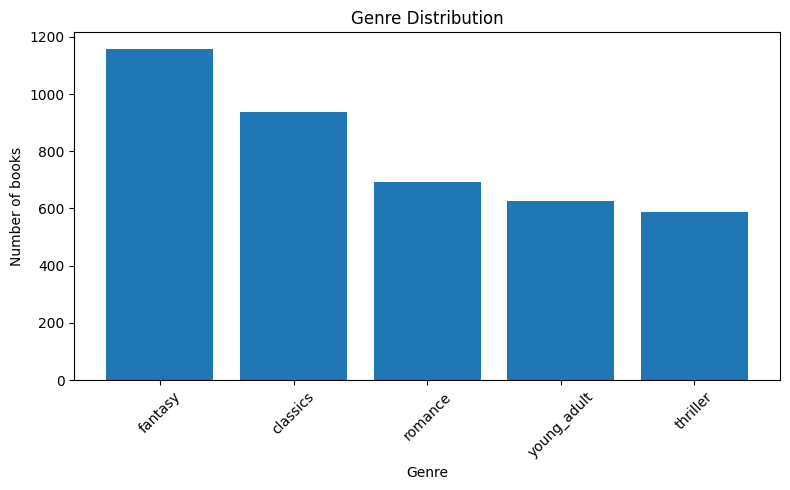

In [14]:
genre_counts = y.value_counts()

genre_distribution = pd.DataFrame({
    "genre": genre_counts.index,
    "count": genre_counts.values,
    "percentage": genre_counts.values / genre_counts.values.sum()
})

plt.figure(figsize=(8, 5))
plt.bar(genre_distribution["genre"], genre_distribution["count"])
plt.xlabel("Genre")
plt.ylabel("Number of books")
plt.title("Genre Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### BNB and MNB pipeline setup & StratifiedKFold cross-validation

In [16]:
bnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", BernoulliNB())
])

mnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### Evaluate multiple classification metrics for BNB & MNB

In [19]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

bnb_cv_results = cross_validate(
    bnb_pipeline,
    X_text,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

mnb_cv_results = cross_validate(
    mnb_pipeline,
    X_text,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

#### Create comparison table for BNB and MNB metric results.

In [20]:
def summarize_cv_results(cv_results, model_name):
    summary = {"model": model_name}
    
    for metric in scoring.keys():
        scores = cv_results[f"test_{metric}"]
        summary[f"{metric}_mean"] = scores.mean()
        summary[f"{metric}_std"] = scores.std()
    
    return summary


comparison_df = pd.DataFrame([
    summarize_cv_results(bnb_cv_results, "BernoulliNB"),
    summarize_cv_results(mnb_cv_results, "MultinomialNB")
])

comparison_df

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,BernoulliNB,0.66525,0.009165,0.619173,0.007236,0.748784,0.014679,0.619173,0.007236,0.643548,0.006935,0.655644,0.007855
1,MultinomialNB,0.72775,0.010937,0.711895,0.010310,0.747217,0.013353,0.711895,0.010310,0.719993,0.010113,0.727815,0.010505


#### Plot the metric comparison

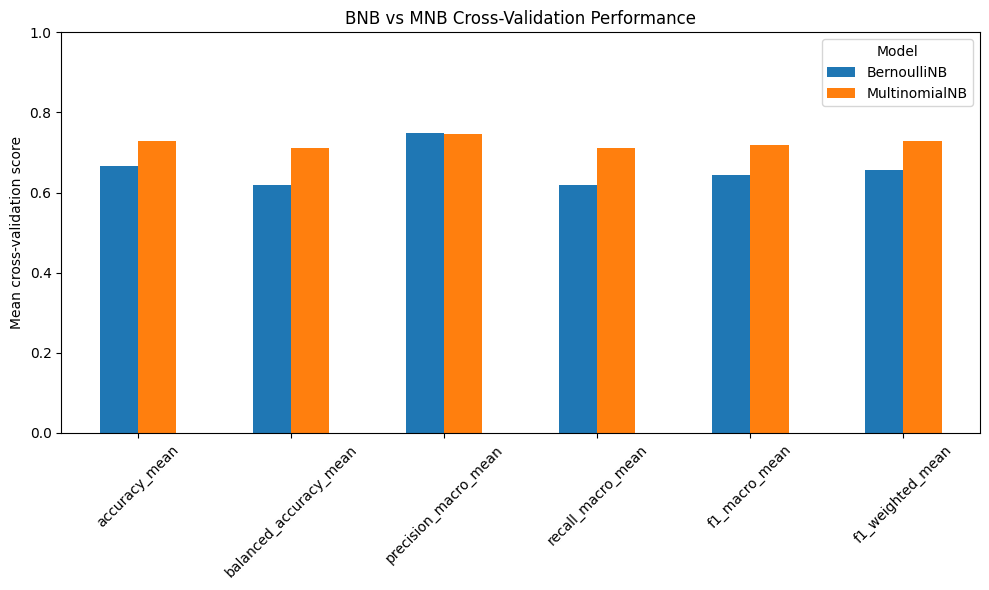

In [ ]:
plot_df = comparison_df.set_index("model")[
    [
        "accuracy_mean",
        "balanced_accuracy_mean",
        "precision_macro_mean",
        "recall_macro_mean",
        "f1_macro_mean",
        "f1_weighted_mean"
    ]
]
plot_df.T.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Mean cross-validation score")
plt.title("BNB vs MNB Cross-Validation Performance")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [22]:
bnb_pred = cross_val_predict(
    bnb_pipeline,
    X_text,
    y,
    cv=cv,
    n_jobs=-1
)

mnb_pred = cross_val_predict(
    mnb_pipeline,
    X_text,
    y,
    cv=cv,
    n_jobs=-1
)

print("BernoulliNB Classification Report")
print(classification_report(y, bnb_pred))

print("MultinomialNB Classification Report")
print(classification_report(y, mnb_pred))

/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


BernoulliNB Classification Report
              precision    recall  f1-score   support

    classics       0.71      0.81      0.75       936
     fantasy       0.55      0.85      0.67      1158
     romance       0.74      0.59      0.66       692
    thriller       0.93      0.47      0.62       588
 young_adult       0.81      0.38      0.52       626

    accuracy                           0.67      4000
   macro avg       0.75      0.62      0.64      4000
weighted avg       0.72      0.67      0.66      4000

MultinomialNB Classification Report
              precision    recall  f1-score   support

    classics       0.79      0.72      0.75       936
     fantasy       0.72      0.82      0.77      1158
     romance       0.59      0.78      0.67       692
    thriller       0.83      0.68      0.75       588
 young_adult       0.80      0.57      0.66       626

    accuracy                           0.73      4000
   macro avg       0.75      0.71      0.72      4000
weighte

/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


#### Confusion matrices for BNB and MNB

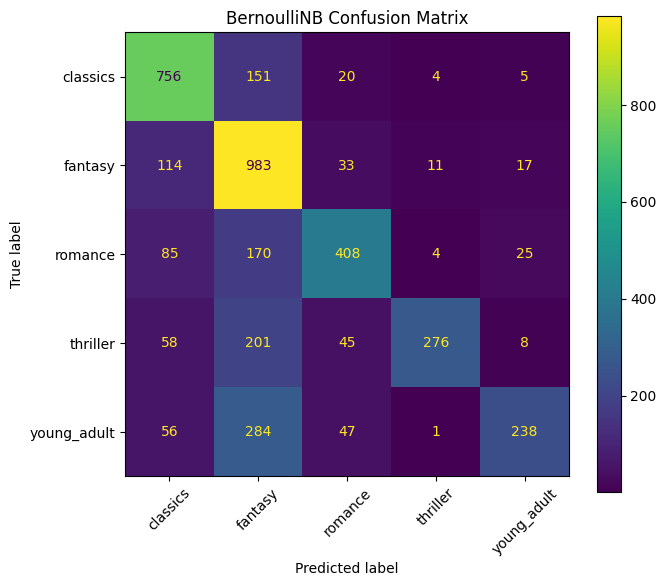

In [23]:
labels_order = sorted(y.unique())

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y,
    bnb_pred,
    labels=labels_order,
    xticks_rotation=45,
    ax=ax
)
plt.title("BernoulliNB Confusion Matrix")
plt.tight_layout()
plt.show()

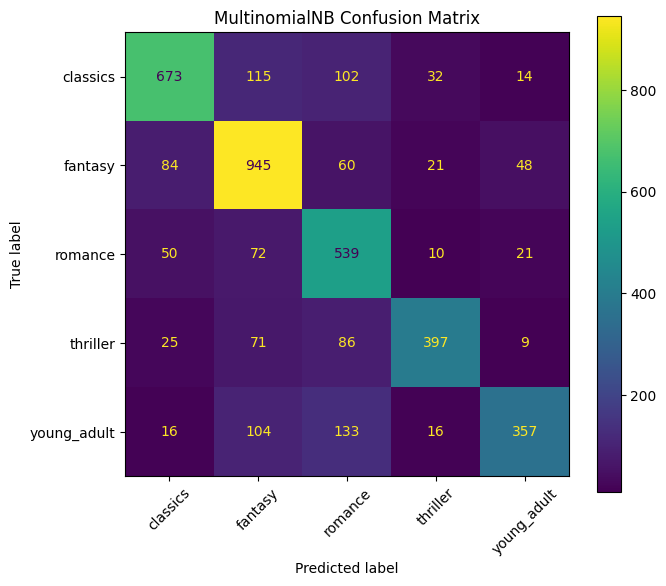

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y,
    mnb_pred,
    labels=labels_order,
    xticks_rotation=45,
    ax=ax
)
plt.title("MultinomialNB Confusion Matrix")
plt.tight_layout()
plt.show()